In [8]:
import glob
import netCDF4 as nc

# Using glob to expand the wildcard path into a list of actual files
file_pattern = '/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*'
file_list = sorted(glob.glob(file_pattern))

if not file_list:
    print(f"Error: No files found matching pattern: {file_pattern}")
else:
    # Open the first available file in the sequence to check variables
    target_file = file_list[0]
    print(f"Checking file: {target_file}\n")
    
    try:
        ncfile = nc.Dataset(target_file)
        
        has_u2 = "wdir10" in ncfile.variables
        has_v2 = "WDIR10" in ncfile.variables
        
        print(f"U2 (2m U-wind) exists: {has_u2}")
        print(f"V2 (2m V-wind) exists: {has_v2}")
        
        if not has_u2:
            print("\nAvailable surface/near-surface variables instead:")
            surface_vars = [v for v in ncfile.variables if any(x in v for x in ["10", "2", "TSK", "PSFC"])]
            print(surface_vars[:15])
            
        ncfile.close()
        
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")


Checking file: /data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-01_00:00:00

U2 (2m U-wind) exists: False
V2 (2m V-wind) exists: False

Available surface/near-surface variables instead:
['TSK_FORCE', 'TSK_FORCE_TEND', 'Q2', 'T2', 'TH2', 'PSFC', 'U10', 'V10', 'AREA2D', 'DX2D', 'CF2', 'SH2O', 'SSTSK', 'U10E', 'V10E']


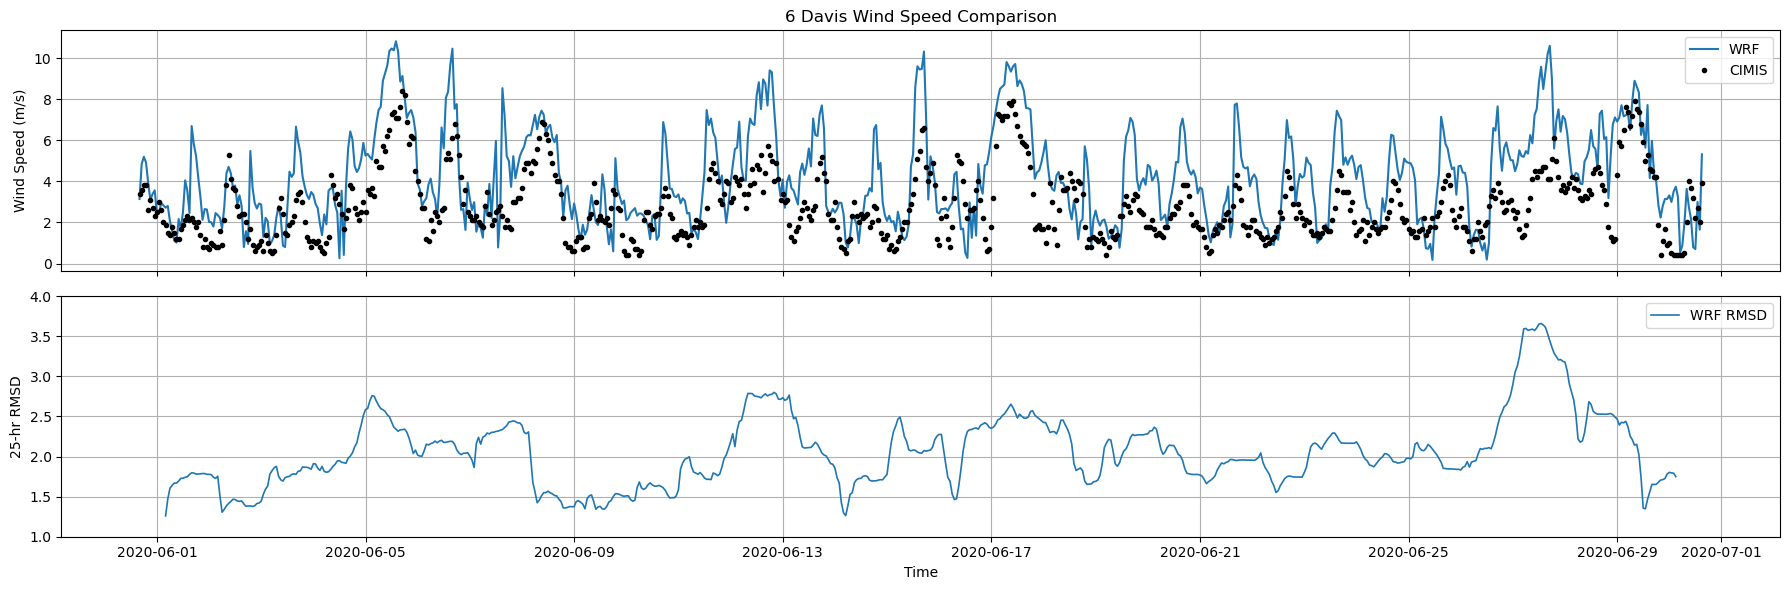

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


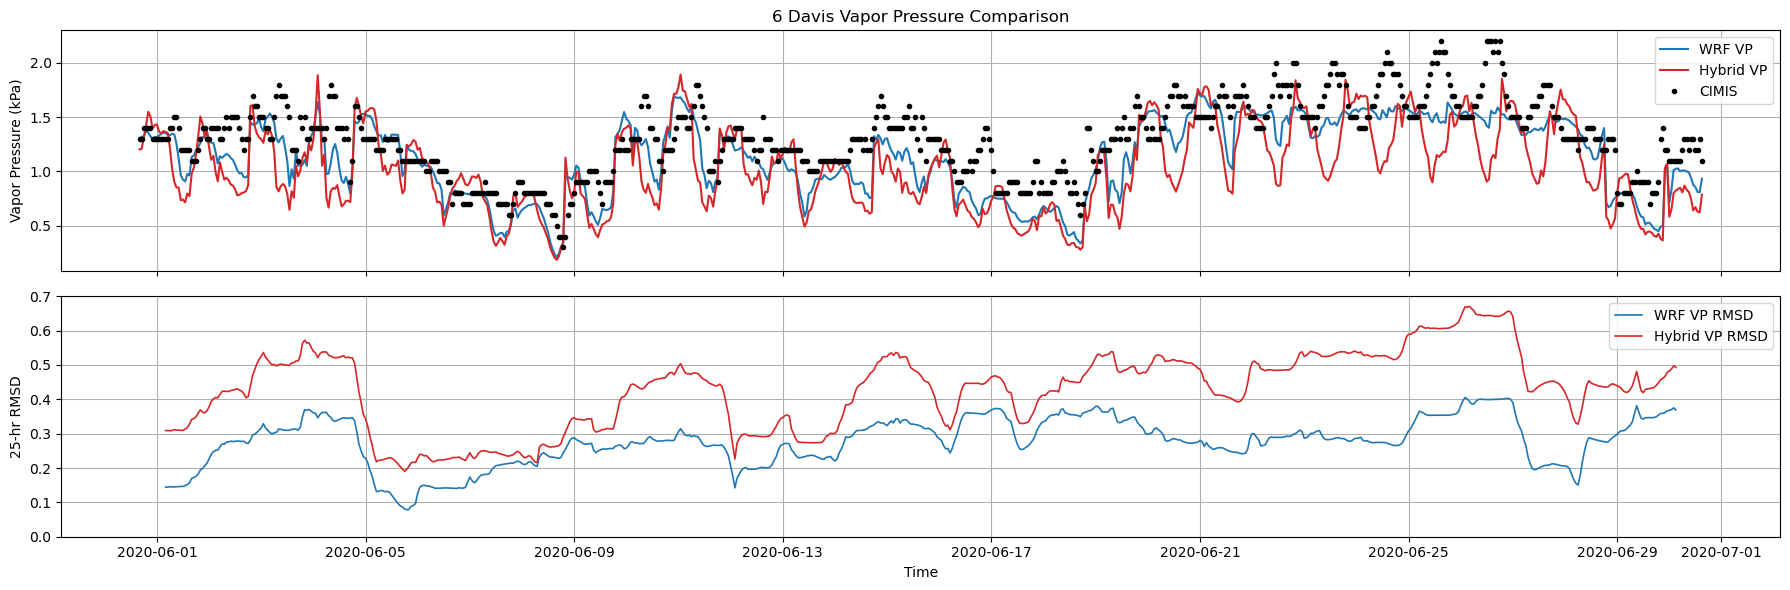

[[-0.17189458707176986, -0.2707582939226973], [0.2840940471984944, 0.43862454696904435], [0.8291199868541393, 0.6598620175879346]]


In [1]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 25   # must be odd

lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

# ===============================
# WRF DATA (wind + T2 + RH2)
# ===============================
Time_w, WRF_wind = MonthGlob(WRFFiles, "wspd10", lat_point, lon_point)
_, WRF_T2        = MonthGlob(WRFFiles, "T2", lat_point, lon_point)
_, WRF_RH2       = MonthGlob(WRFFiles, "rh2", lat_point, lon_point)

wrf_time = []
wrf_wind_vals = []
wrf_t2_vals = []
wrf_rh2_vals = []

for t, w, T, RH in zip(Time_w, WRF_wind[0], WRF_T2[0], WRF_RH2[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_wind_vals.append(w)
    wrf_t2_vals.append(T)
    wrf_rh2_vals.append(RH)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)
midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_wind = df["Wind Speed (m/s)"]
cimis_vp   = df["Vap Pres (kPa)"]
cimis_tair = df["Air Temp (C)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_wind), len(wrf_wind_vals))

Time = list(cimis_time[:min_len])

# ===============================
# VAPOR PRESSURE CALCULATION
# ===============================
L = 2.5e6
Rv = 461.0

# --- WRF vapor pressure ---
es_wrf = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / np.array(wrf_t2_vals[:min_len]))))
e_wrf = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_wrf / 10.0  # kPa

# --- Hybrid vapor pressure ---
Tair_K = np.array(cimis_tair[:min_len]) + 273.15
es_hybrid = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K)))
e_hybrid = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_hybrid / 10.0  # kPa

# ===============================
# WIND SPEED ARRAYS
# ===============================
Vals_wind = [
    list(cimis_wind[:min_len]),
    list(wrf_wind_vals[:min_len])
]

Legend_wind = ["CIMIS", "WRF"]

stats_wind = MonthTimeSeries(
    Time,
    Vals_wind,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend_wind,
    Show=True,
    Window=WINDOW
)

# ===============================
# VAPOR PRESSURE ARRAYS (NEW PLOT)
# ===============================
Vals_vp = [
    list(cimis_vp[:min_len]),
    list(e_wrf),
    list(e_hybrid)
]

Legend_vp = ["CIMIS", "WRF VP", "Hybrid VP"]

stats_vp = MonthTimeSeries(
    Time,
    Vals_vp,
    Title=f"{stn_id} {stn_name} Vapor Pressure Comparison",
    YLabel="Vapor Pressure (kPa)",
    Legend=Legend_vp,
    Show=True,
    Window=WINDOW
)

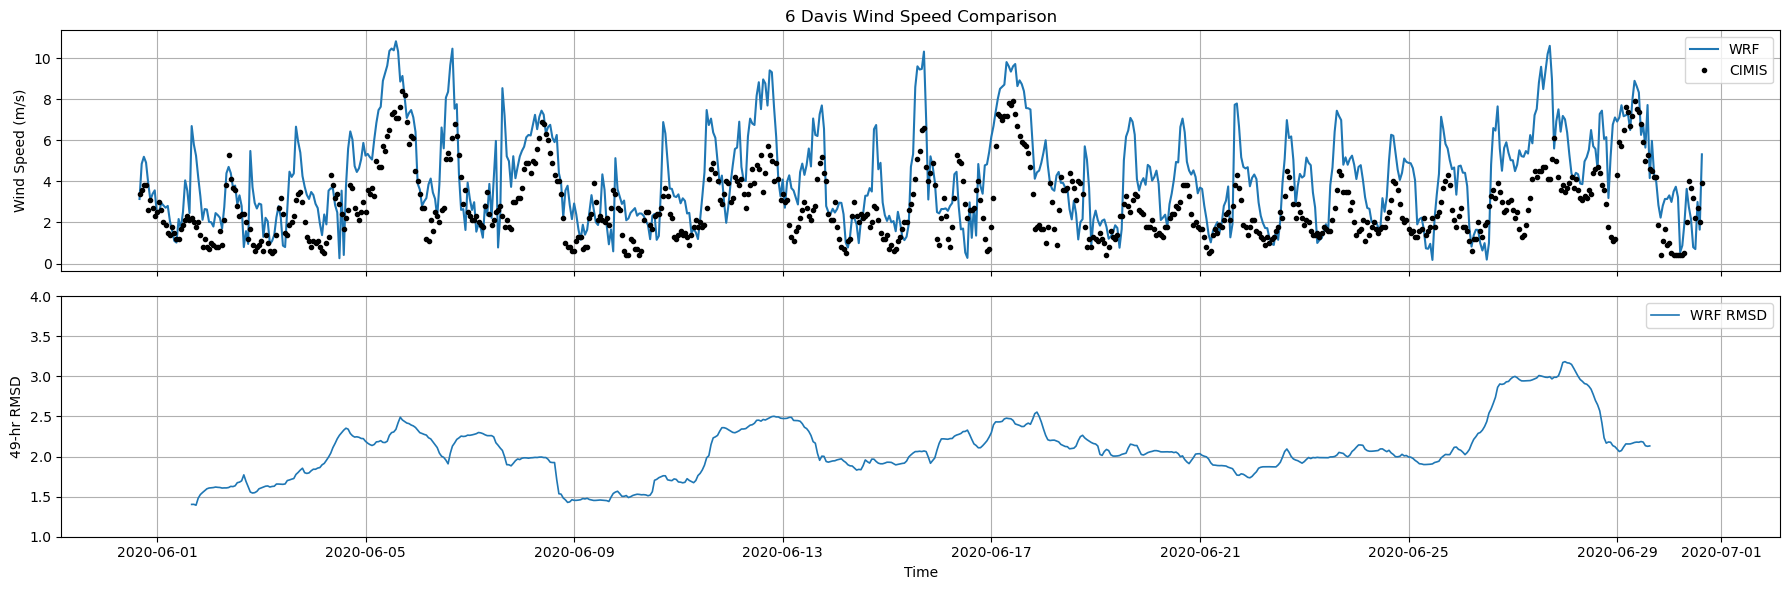

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


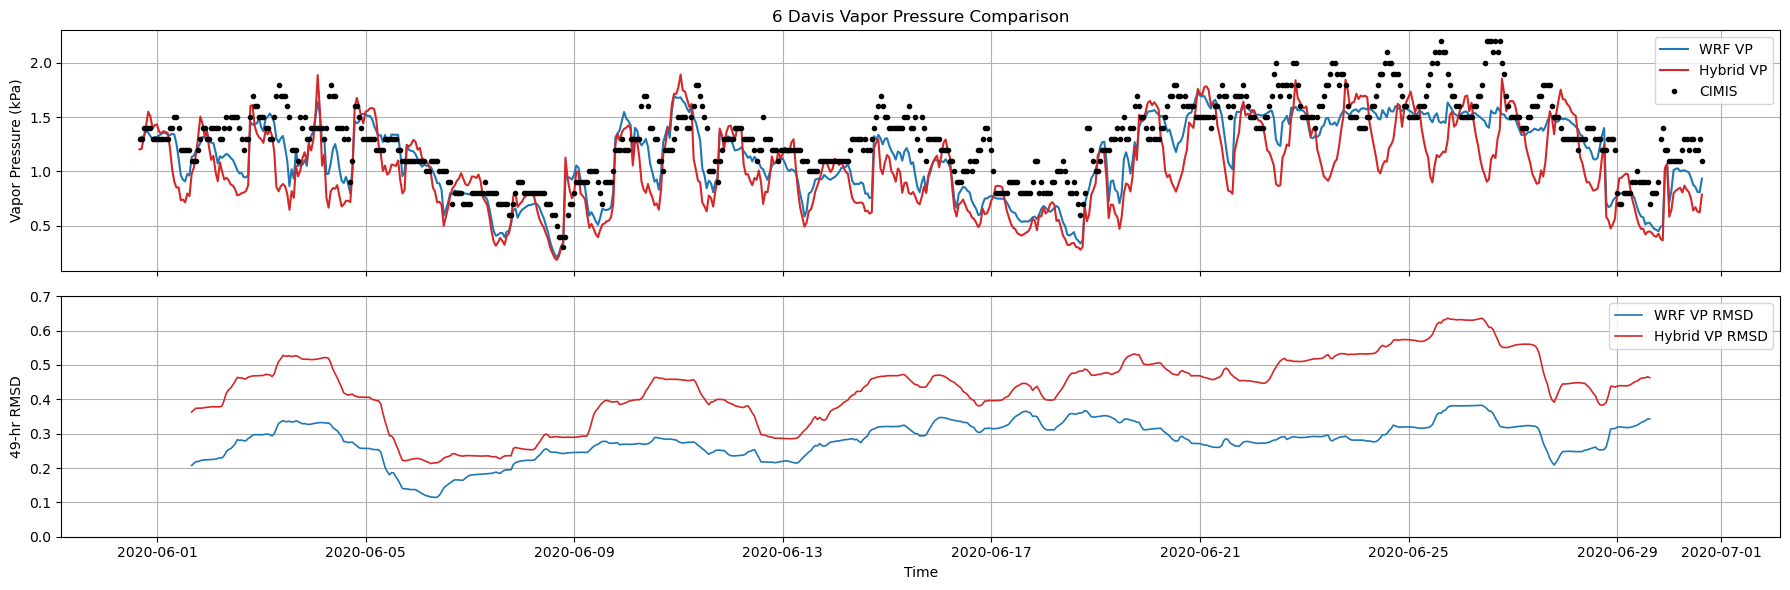

[[-0.17189458707176986, -0.2707582939226973], [0.2840940471984944, 0.43862454696904435], [0.8291199868541393, 0.6598620175879346]]


In [2]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 49   # must be odd

lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

# ===============================
# WRF DATA (wind + T2 + RH2)
# ===============================
Time_w, WRF_wind = MonthGlob(WRFFiles, "wspd10", lat_point, lon_point)
_, WRF_T2        = MonthGlob(WRFFiles, "T2", lat_point, lon_point)
_, WRF_RH2       = MonthGlob(WRFFiles, "rh2", lat_point, lon_point)

wrf_time = []
wrf_wind_vals = []
wrf_t2_vals = []
wrf_rh2_vals = []

for t, w, T, RH in zip(Time_w, WRF_wind[0], WRF_T2[0], WRF_RH2[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_wind_vals.append(w)
    wrf_t2_vals.append(T)
    wrf_rh2_vals.append(RH)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)
midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_wind = df["Wind Speed (m/s)"]
cimis_vp   = df["Vap Pres (kPa)"]
cimis_tair = df["Air Temp (C)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_wind), len(wrf_wind_vals))

Time = list(cimis_time[:min_len])

# ===============================
# VAPOR PRESSURE CALCULATION
# ===============================
L = 2.5e6
Rv = 461.0

# --- WRF vapor pressure ---
es_wrf = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / np.array(wrf_t2_vals[:min_len]))))
e_wrf = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_wrf / 10.0  # kPa

# --- Hybrid vapor pressure ---
Tair_K = np.array(cimis_tair[:min_len]) + 273.15
es_hybrid = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K)))
e_hybrid = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_hybrid / 10.0  # kPa

# ===============================
# WIND SPEED ARRAYS
# ===============================
Vals_wind = [
    list(cimis_wind[:min_len]),
    list(wrf_wind_vals[:min_len])
]

Legend_wind = ["CIMIS", "WRF"]

stats_wind = MonthTimeSeries(
    Time,
    Vals_wind,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend_wind,
    Show=True,
    Window=WINDOW
)

# ===============================
# VAPOR PRESSURE ARRAYS (NEW PLOT)
# ===============================
Vals_vp = [
    list(cimis_vp[:min_len]),
    list(e_wrf),
    list(e_hybrid)
]

Legend_vp = ["CIMIS", "WRF VP", "Hybrid VP"]

stats_vp = MonthTimeSeries(
    Time,
    Vals_vp,
    Title=f"{stn_id} {stn_name} Vapor Pressure Comparison",
    YLabel="Vapor Pressure (kPa)",
    Legend=Legend_vp,
    Show=True,
    Window=WINDOW
)

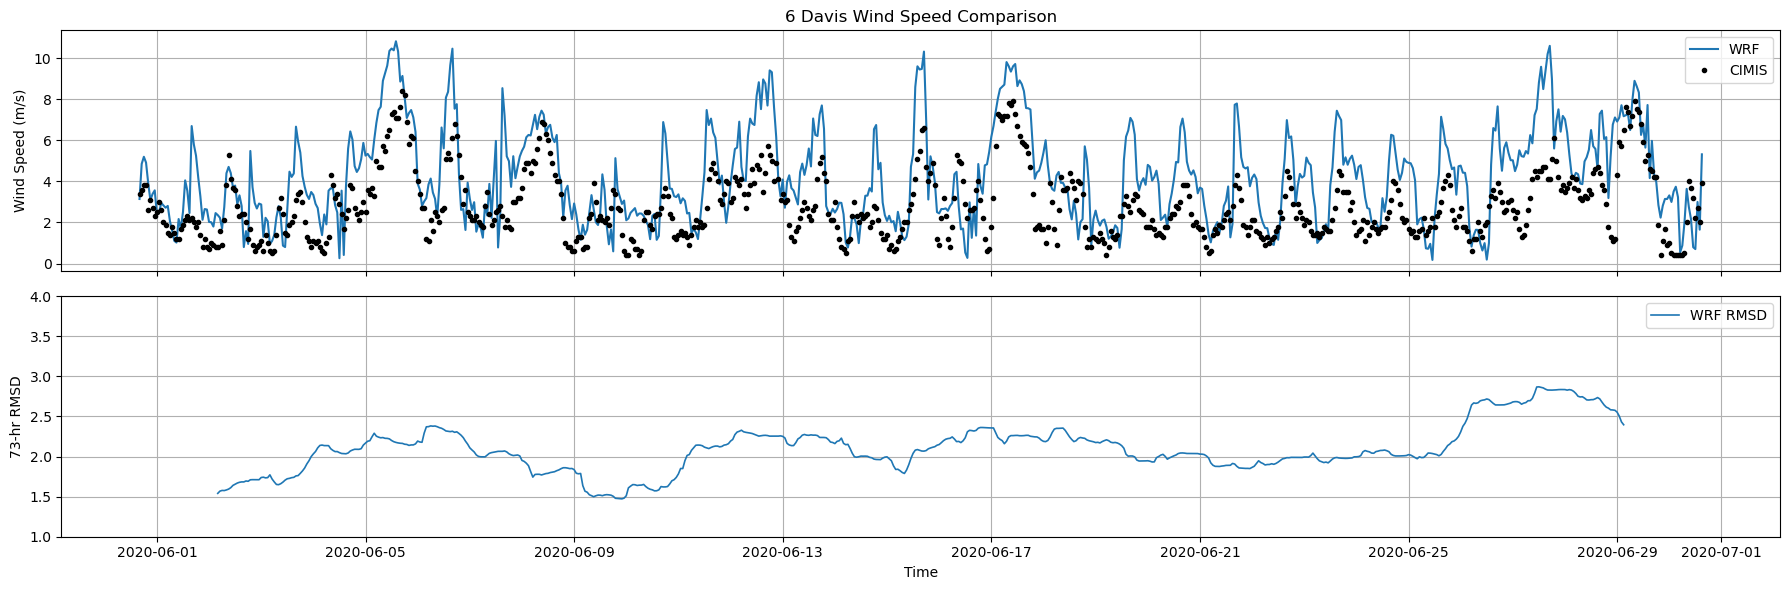

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


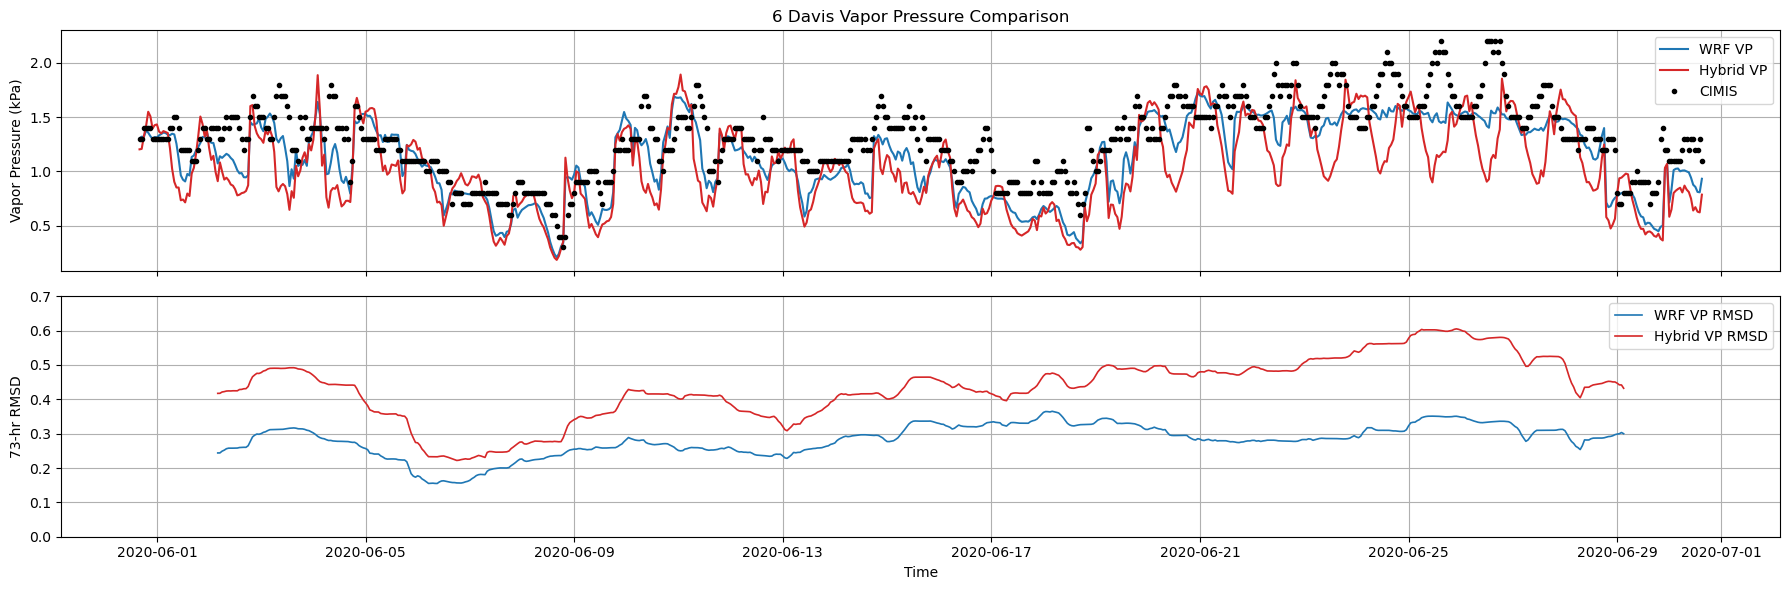

[[-0.17189458707176986, -0.2707582939226973], [0.2840940471984944, 0.43862454696904435], [0.8291199868541393, 0.6598620175879346]]


In [3]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 73   # must be odd

lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

# ===============================
# WRF DATA (wind + T2 + RH2)
# ===============================
Time_w, WRF_wind = MonthGlob(WRFFiles, "wspd10", lat_point, lon_point)
_, WRF_T2        = MonthGlob(WRFFiles, "T2", lat_point, lon_point)
_, WRF_RH2       = MonthGlob(WRFFiles, "rh2", lat_point, lon_point)

wrf_time = []
wrf_wind_vals = []
wrf_t2_vals = []
wrf_rh2_vals = []

for t, w, T, RH in zip(Time_w, WRF_wind[0], WRF_T2[0], WRF_RH2[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_wind_vals.append(w)
    wrf_t2_vals.append(T)
    wrf_rh2_vals.append(RH)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)
midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_wind = df["Wind Speed (m/s)"]
cimis_vp   = df["Vap Pres (kPa)"]
cimis_tair = df["Air Temp (C)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_wind), len(wrf_wind_vals))

Time = list(cimis_time[:min_len])

# ===============================
# VAPOR PRESSURE CALCULATION
# ===============================
L = 2.5e6
Rv = 461.0

# --- WRF vapor pressure ---
es_wrf = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / np.array(wrf_t2_vals[:min_len]))))
e_wrf = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_wrf / 10.0  # kPa

# --- Hybrid vapor pressure ---
Tair_K = np.array(cimis_tair[:min_len]) + 273.15
es_hybrid = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K)))
e_hybrid = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_hybrid / 10.0  # kPa

# ===============================
# WIND SPEED ARRAYS
# ===============================
Vals_wind = [
    list(cimis_wind[:min_len]),
    list(wrf_wind_vals[:min_len])
]

Legend_wind = ["CIMIS", "WRF"]

stats_wind = MonthTimeSeries(
    Time,
    Vals_wind,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend_wind,
    Show=True,
    Window=WINDOW
)

# ===============================
# VAPOR PRESSURE ARRAYS (NEW PLOT)
# ===============================
Vals_vp = [
    list(cimis_vp[:min_len]),
    list(e_wrf),
    list(e_hybrid)
]

Legend_vp = ["CIMIS", "WRF VP", "Hybrid VP"]

stats_vp = MonthTimeSeries(
    Time,
    Vals_vp,
    Title=f"{stn_id} {stn_name} Vapor Pressure Comparison",
    YLabel="Vapor Pressure (kPa)",
    Legend=Legend_vp,
    Show=True,
    Window=WINDOW
)

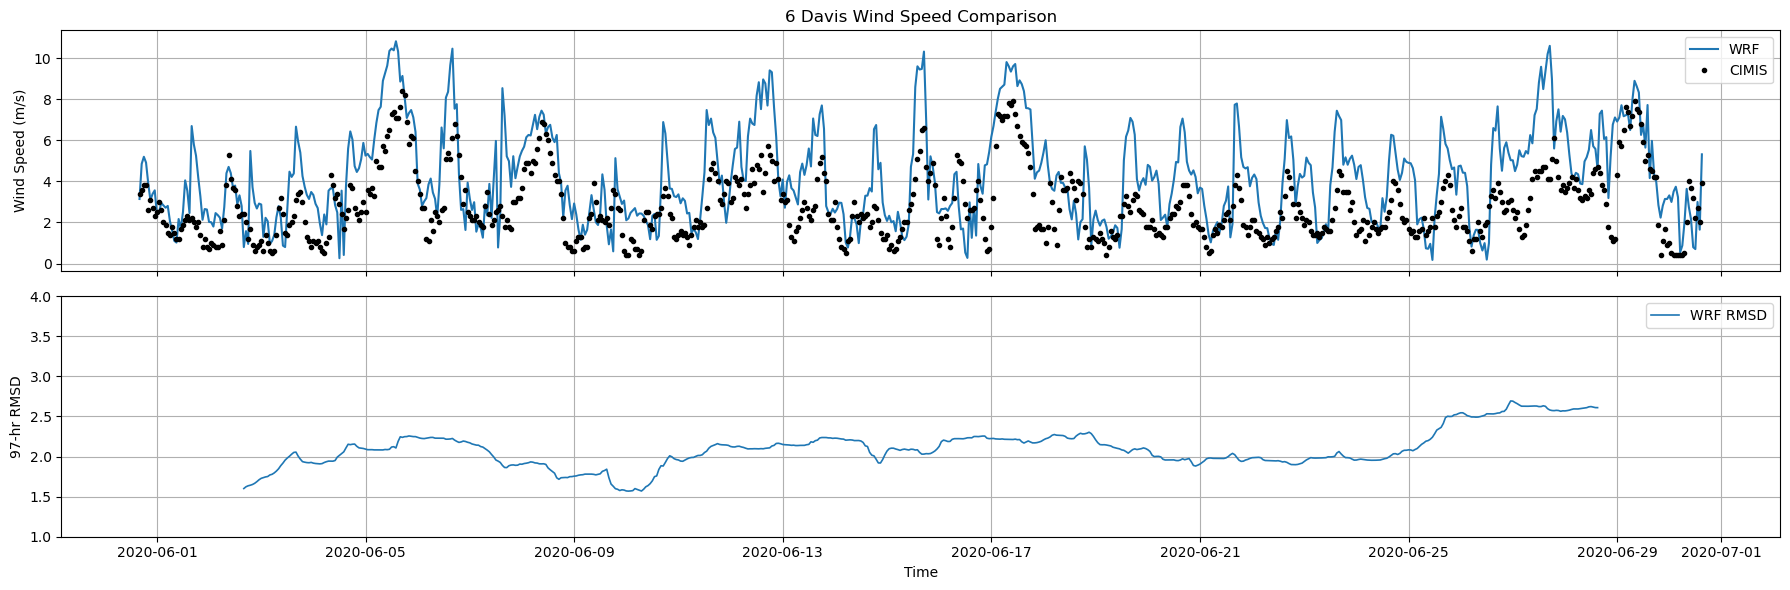

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


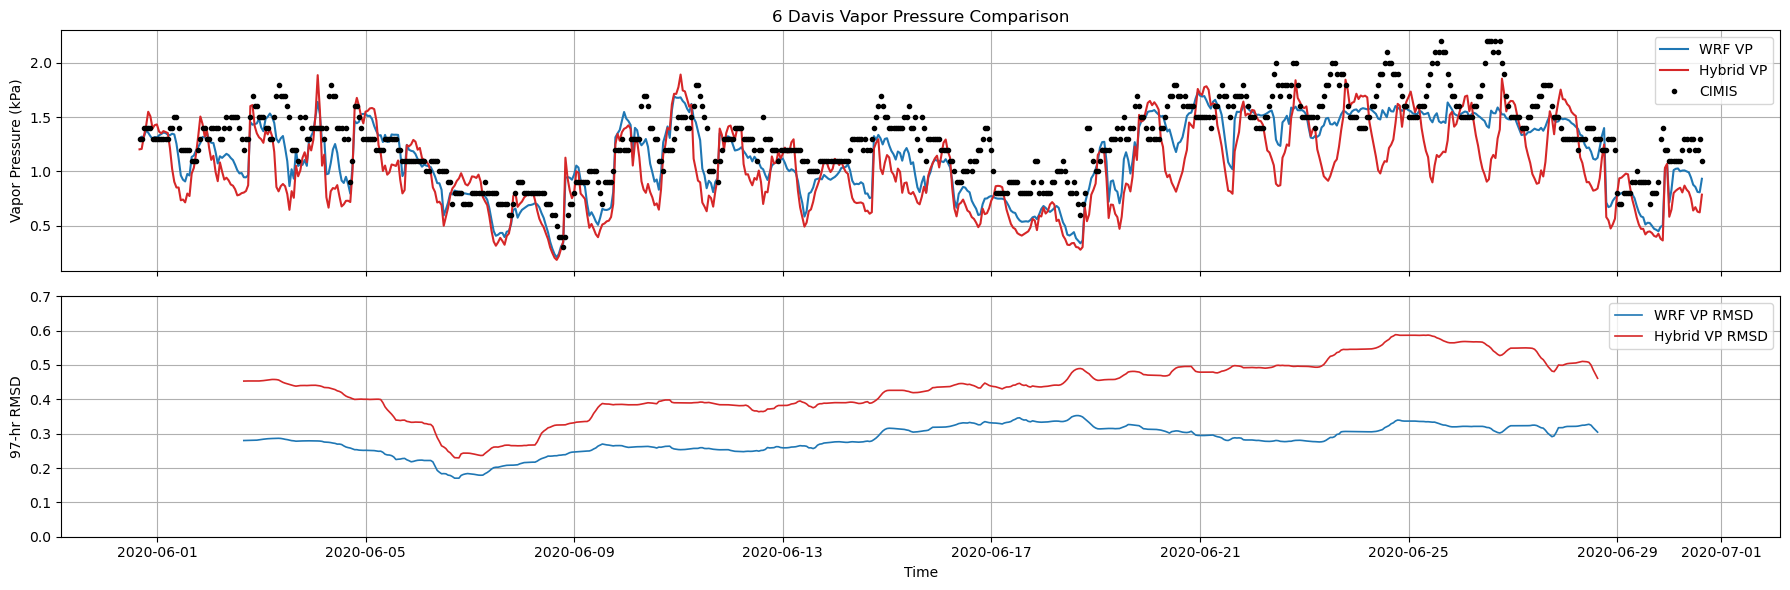

[[-0.17189458707176986, -0.2707582939226973], [0.2840940471984944, 0.43862454696904435], [0.8291199868541393, 0.6598620175879346]]


In [4]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 97   # must be odd

lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

# ===============================
# WRF DATA (wind + T2 + RH2)
# ===============================
Time_w, WRF_wind = MonthGlob(WRFFiles, "wspd10", lat_point, lon_point)
_, WRF_T2        = MonthGlob(WRFFiles, "T2", lat_point, lon_point)
_, WRF_RH2       = MonthGlob(WRFFiles, "rh2", lat_point, lon_point)

wrf_time = []
wrf_wind_vals = []
wrf_t2_vals = []
wrf_rh2_vals = []

for t, w, T, RH in zip(Time_w, WRF_wind[0], WRF_T2[0], WRF_RH2[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_wind_vals.append(w)
    wrf_t2_vals.append(T)
    wrf_rh2_vals.append(RH)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)
midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_wind = df["Wind Speed (m/s)"]
cimis_vp   = df["Vap Pres (kPa)"]
cimis_tair = df["Air Temp (C)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_wind), len(wrf_wind_vals))

Time = list(cimis_time[:min_len])

# ===============================
# VAPOR PRESSURE CALCULATION
# ===============================
L = 2.5e6
Rv = 461.0

# --- WRF vapor pressure ---
es_wrf = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / np.array(wrf_t2_vals[:min_len]))))
e_wrf = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_wrf / 10.0  # kPa

# --- Hybrid vapor pressure ---
Tair_K = np.array(cimis_tair[:min_len]) + 273.15
es_hybrid = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K)))
e_hybrid = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_hybrid / 10.0  # kPa

# ===============================
# WIND SPEED ARRAYS
# ===============================
Vals_wind = [
    list(cimis_wind[:min_len]),
    list(wrf_wind_vals[:min_len])
]

Legend_wind = ["CIMIS", "WRF"]

stats_wind = MonthTimeSeries(
    Time,
    Vals_wind,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend_wind,
    Show=True,
    Window=WINDOW
)

# ===============================
# VAPOR PRESSURE ARRAYS (NEW PLOT)
# ===============================
Vals_vp = [
    list(cimis_vp[:min_len]),
    list(e_wrf),
    list(e_hybrid)
]

Legend_vp = ["CIMIS", "WRF VP", "Hybrid VP"]

stats_vp = MonthTimeSeries(
    Time,
    Vals_vp,
    Title=f"{stn_id} {stn_name} Vapor Pressure Comparison",
    YLabel="Vapor Pressure (kPa)",
    Legend=Legend_vp,
    Show=True,
    Window=WINDOW
)

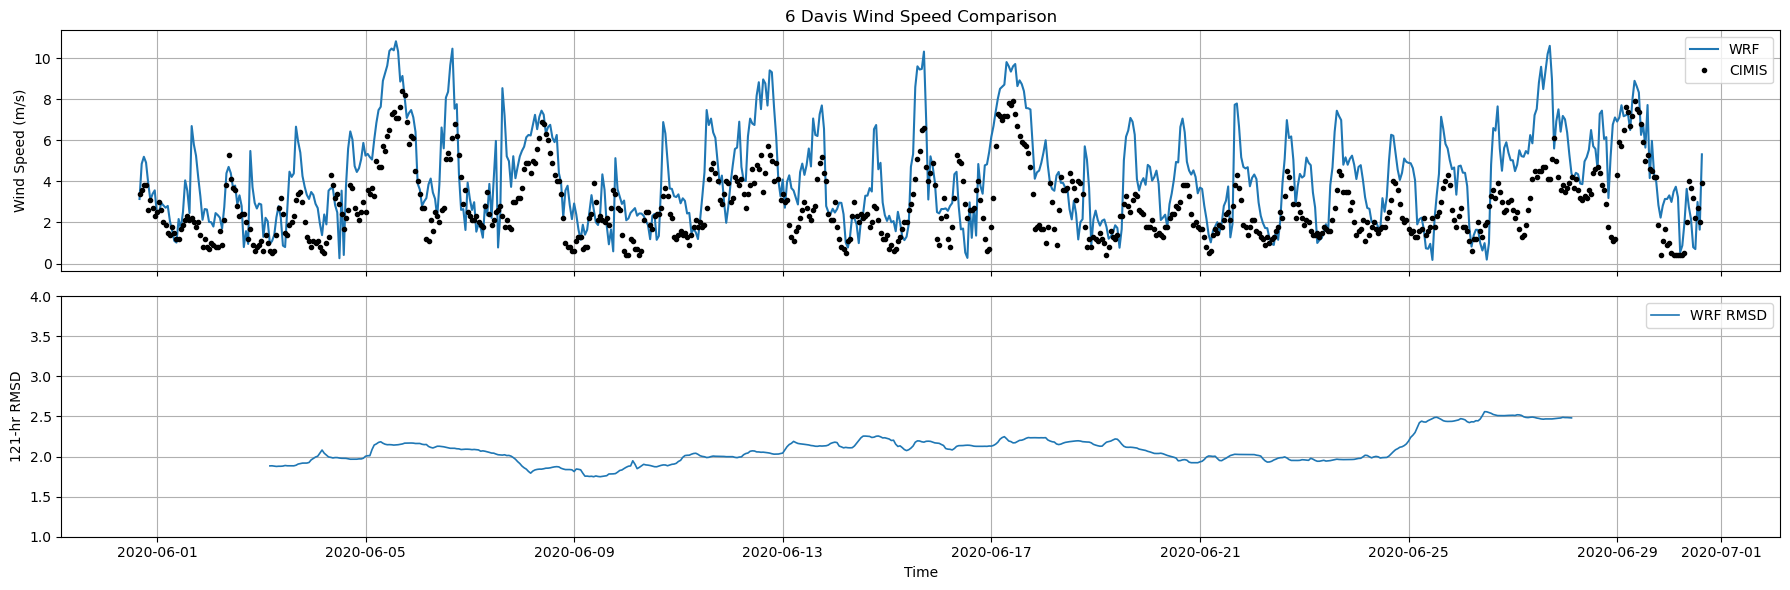

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


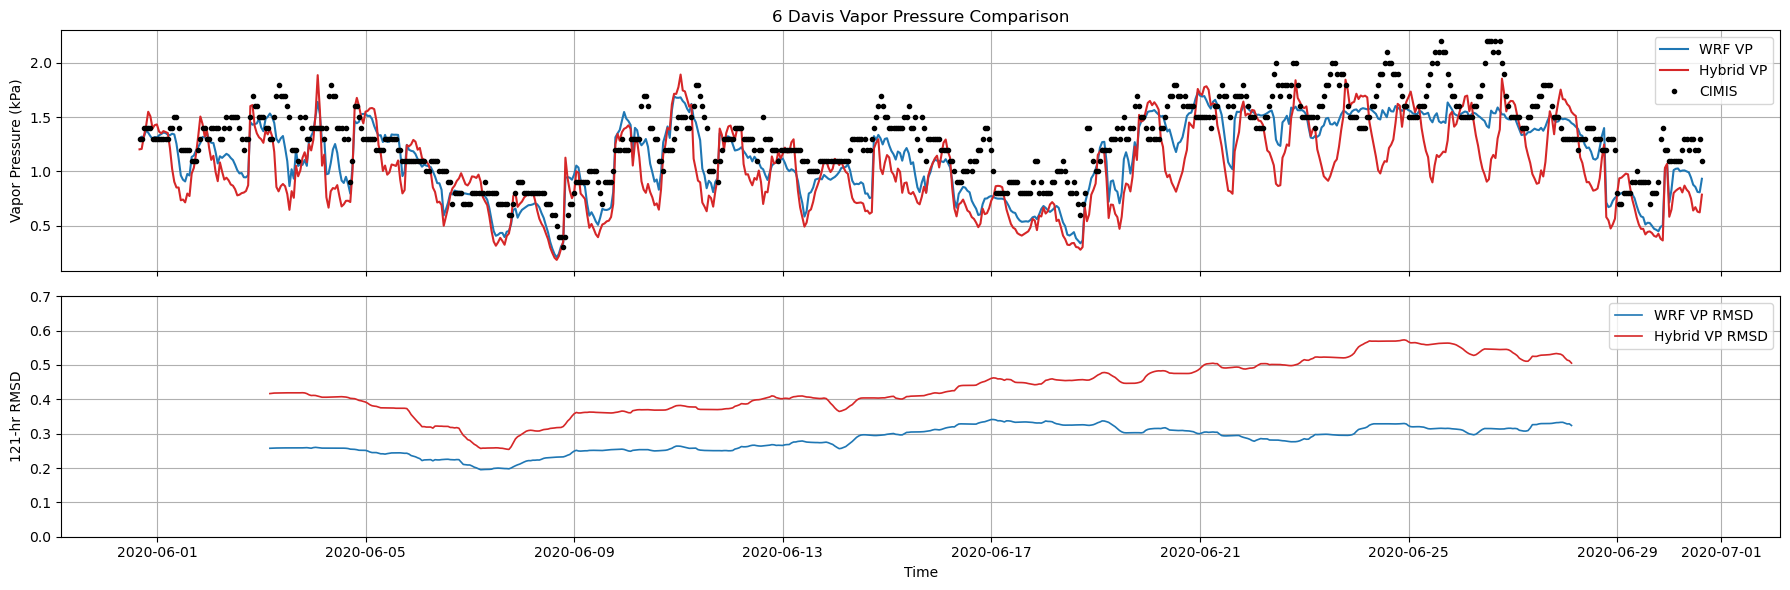

[[-0.17189458707176986, -0.2707582939226973], [0.2840940471984944, 0.43862454696904435], [0.8291199868541393, 0.6598620175879346]]


In [5]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 121   # must be odd

lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

# ===============================
# WRF DATA (wind + T2 + RH2)
# ===============================
Time_w, WRF_wind = MonthGlob(WRFFiles, "wspd10", lat_point, lon_point)
_, WRF_T2        = MonthGlob(WRFFiles, "T2", lat_point, lon_point)
_, WRF_RH2       = MonthGlob(WRFFiles, "rh2", lat_point, lon_point)

wrf_time = []
wrf_wind_vals = []
wrf_t2_vals = []
wrf_rh2_vals = []

for t, w, T, RH in zip(Time_w, WRF_wind[0], WRF_T2[0], WRF_RH2[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_wind_vals.append(w)
    wrf_t2_vals.append(T)
    wrf_rh2_vals.append(RH)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)
midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_wind = df["Wind Speed (m/s)"]
cimis_vp   = df["Vap Pres (kPa)"]
cimis_tair = df["Air Temp (C)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_wind), len(wrf_wind_vals))

Time = list(cimis_time[:min_len])

# ===============================
# VAPOR PRESSURE CALCULATION
# ===============================
L = 2.5e6
Rv = 461.0

# --- WRF vapor pressure ---
es_wrf = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / np.array(wrf_t2_vals[:min_len]))))
e_wrf = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_wrf / 10.0  # kPa

# --- Hybrid vapor pressure ---
Tair_K = np.array(cimis_tair[:min_len]) + 273.15
es_hybrid = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K)))
e_hybrid = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_hybrid / 10.0  # kPa

# ===============================
# WIND SPEED ARRAYS
# ===============================
Vals_wind = [
    list(cimis_wind[:min_len]),
    list(wrf_wind_vals[:min_len])
]

Legend_wind = ["CIMIS", "WRF"]

stats_wind = MonthTimeSeries(
    Time,
    Vals_wind,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend_wind,
    Show=True,
    Window=WINDOW
)

# ===============================
# VAPOR PRESSURE ARRAYS (NEW PLOT)
# ===============================
Vals_vp = [
    list(cimis_vp[:min_len]),
    list(e_wrf),
    list(e_hybrid)
]

Legend_vp = ["CIMIS", "WRF VP", "Hybrid VP"]

stats_vp = MonthTimeSeries(
    Time,
    Vals_vp,
    Title=f"{stn_id} {stn_name} Vapor Pressure Comparison",
    YLabel="Vapor Pressure (kPa)",
    Legend=Legend_vp,
    Show=True,
    Window=WINDOW
)

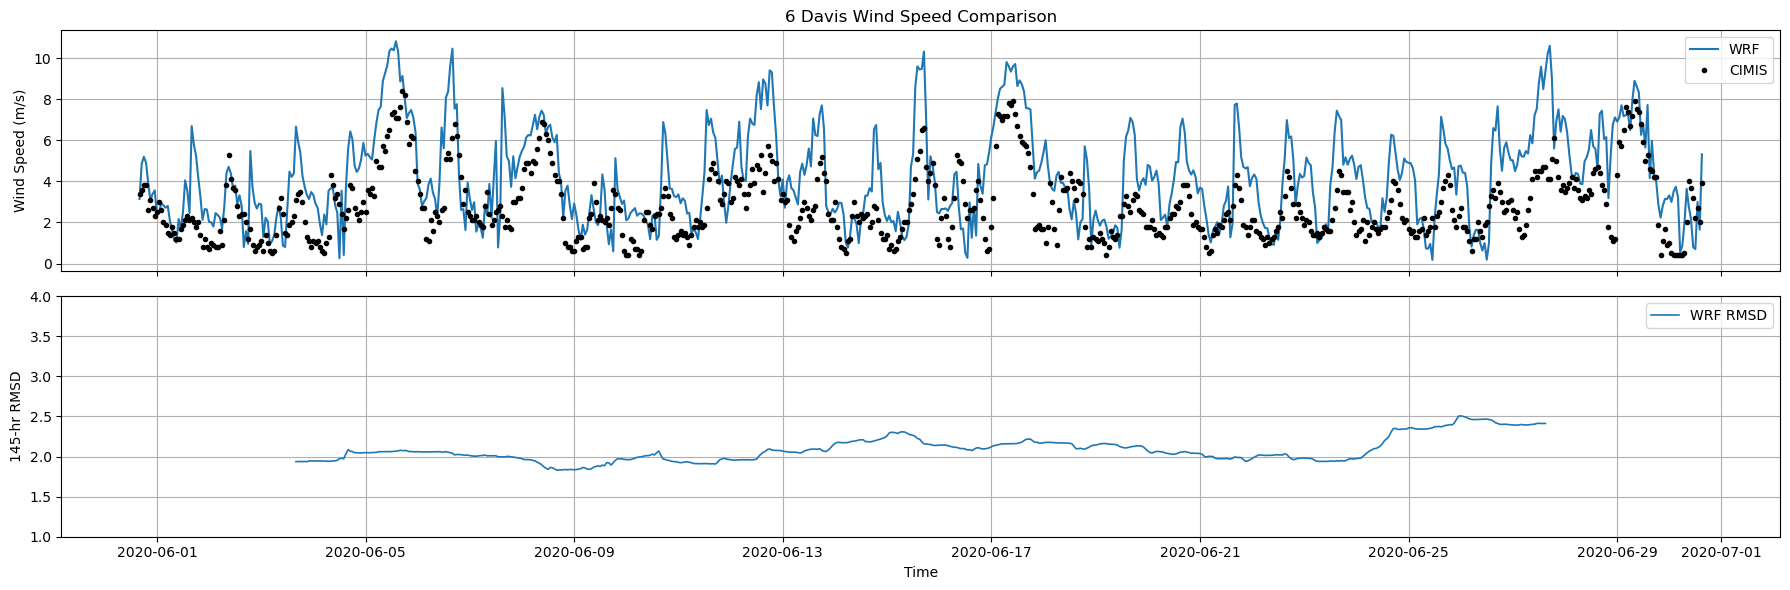

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


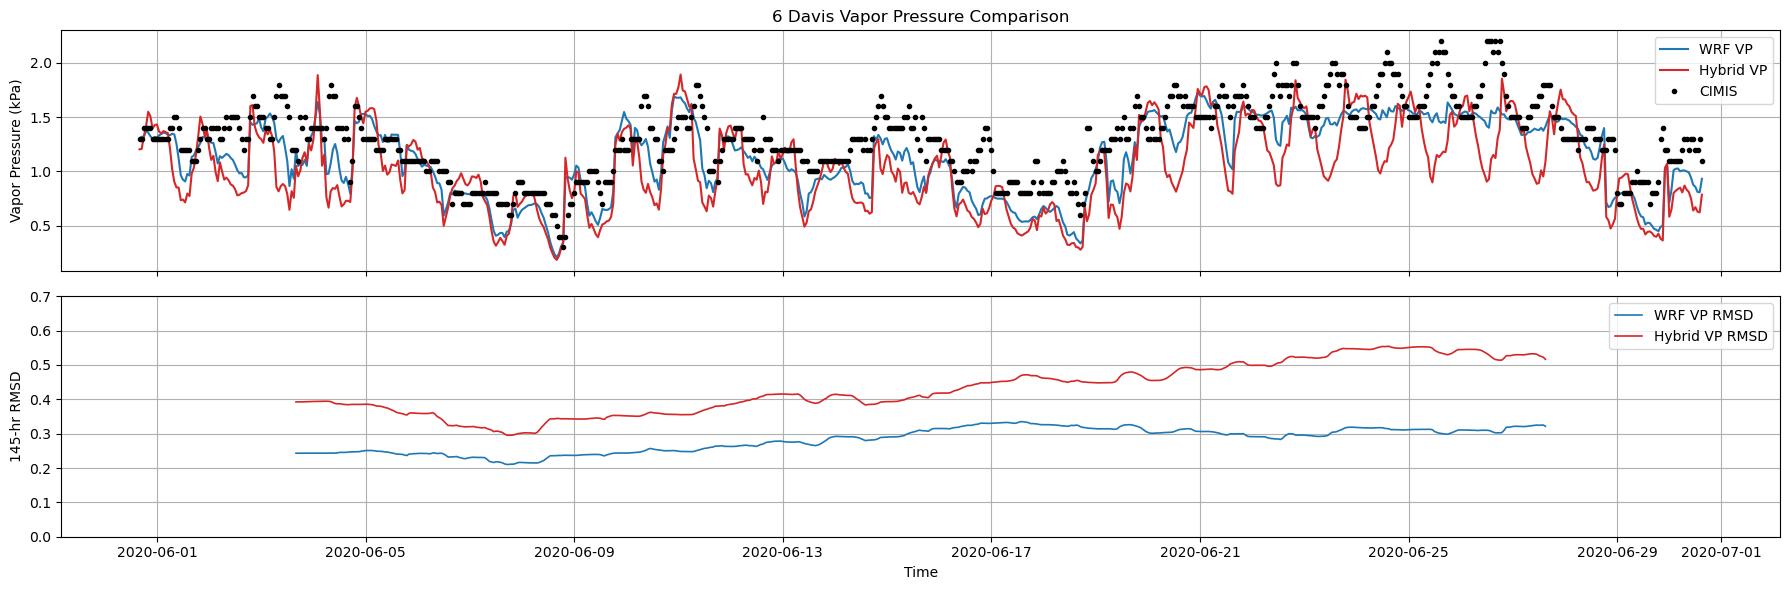

[[-0.17189458707176986, -0.2707582939226973], [0.2840940471984944, 0.43862454696904435], [0.8291199868541393, 0.6598620175879346]]


In [6]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 145   # must be odd

lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

# ===============================
# WRF DATA (wind + T2 + RH2)
# ===============================
Time_w, WRF_wind = MonthGlob(WRFFiles, "wspd10", lat_point, lon_point)
_, WRF_T2        = MonthGlob(WRFFiles, "T2", lat_point, lon_point)
_, WRF_RH2       = MonthGlob(WRFFiles, "rh2", lat_point, lon_point)

wrf_time = []
wrf_wind_vals = []
wrf_t2_vals = []
wrf_rh2_vals = []

for t, w, T, RH in zip(Time_w, WRF_wind[0], WRF_T2[0], WRF_RH2[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_wind_vals.append(w)
    wrf_t2_vals.append(T)
    wrf_rh2_vals.append(RH)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)
midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_wind = df["Wind Speed (m/s)"]
cimis_vp   = df["Vap Pres (kPa)"]
cimis_tair = df["Air Temp (C)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_wind), len(wrf_wind_vals))

Time = list(cimis_time[:min_len])

# ===============================
# VAPOR PRESSURE CALCULATION
# ===============================
L = 2.5e6
Rv = 461.0

# --- WRF vapor pressure ---
es_wrf = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / np.array(wrf_t2_vals[:min_len]))))
e_wrf = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_wrf / 10.0  # kPa

# --- Hybrid vapor pressure ---
Tair_K = np.array(cimis_tair[:min_len]) + 273.15
es_hybrid = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K)))
e_hybrid = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_hybrid / 10.0  # kPa

# ===============================
# WIND SPEED ARRAYS
# ===============================
Vals_wind = [
    list(cimis_wind[:min_len]),
    list(wrf_wind_vals[:min_len])
]

Legend_wind = ["CIMIS", "WRF"]

stats_wind = MonthTimeSeries(
    Time,
    Vals_wind,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend_wind,
    Show=True,
    Window=WINDOW
)

# ===============================
# VAPOR PRESSURE ARRAYS (NEW PLOT)
# ===============================
Vals_vp = [
    list(cimis_vp[:min_len]),
    list(e_wrf),
    list(e_hybrid)
]

Legend_vp = ["CIMIS", "WRF VP", "Hybrid VP"]

stats_vp = MonthTimeSeries(
    Time,
    Vals_vp,
    Title=f"{stn_id} {stn_name} Vapor Pressure Comparison",
    YLabel="Vapor Pressure (kPa)",
    Legend=Legend_vp,
    Show=True,
    Window=WINDOW
)

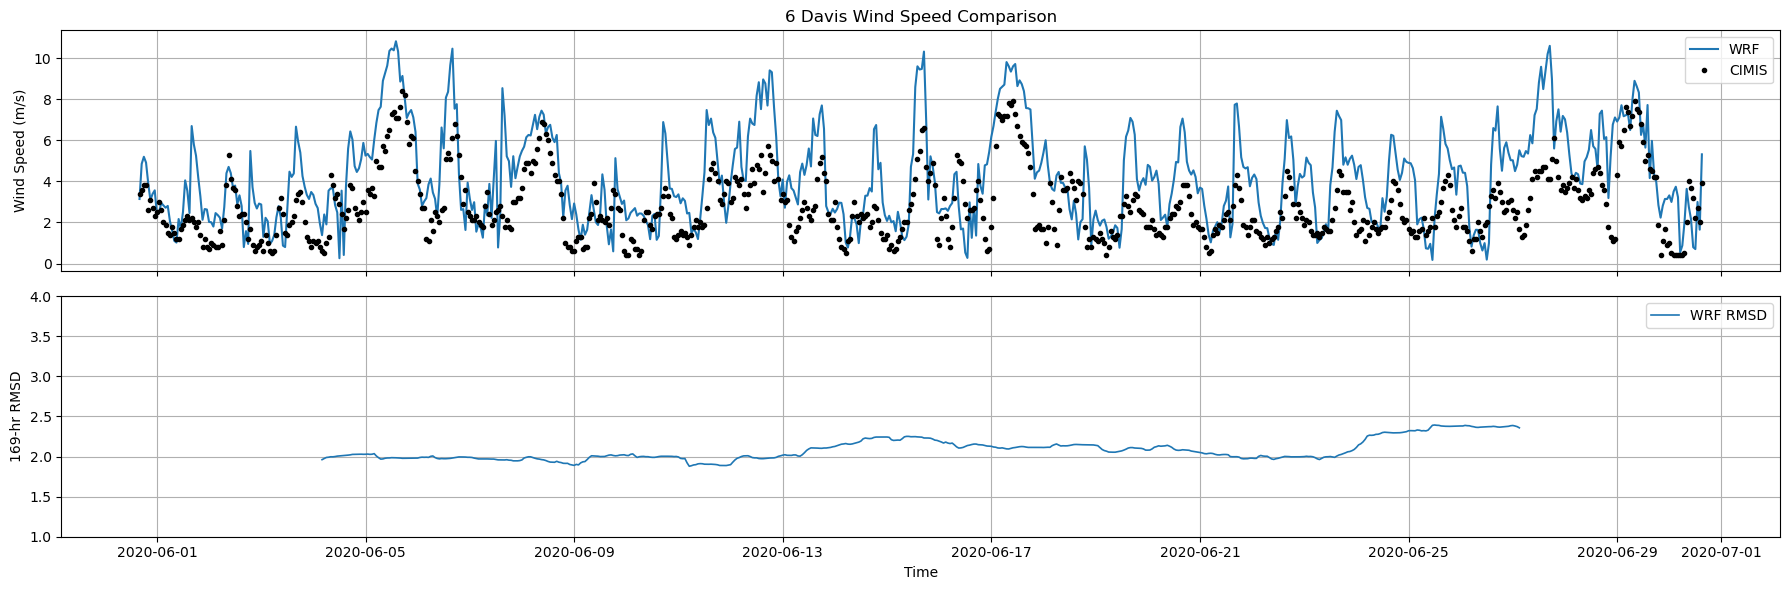

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


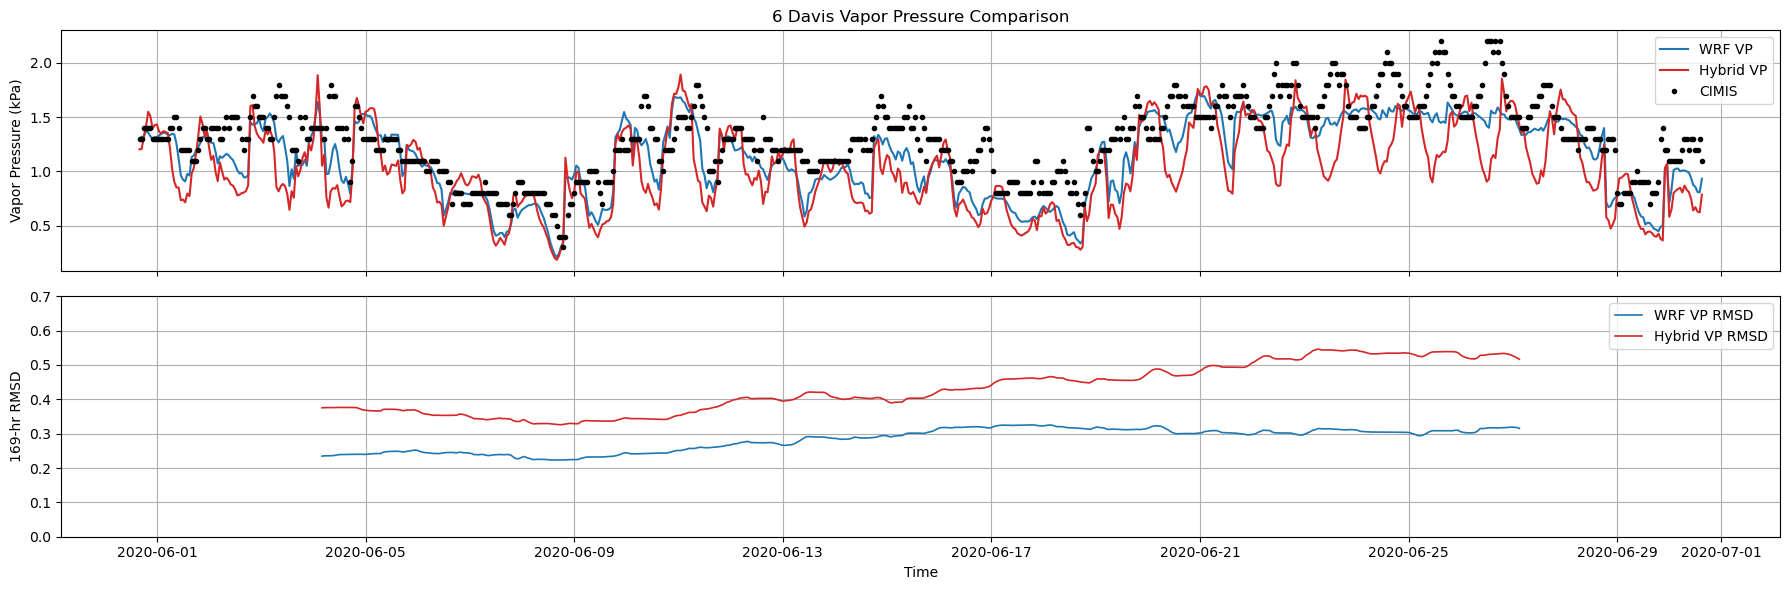

[[-0.17189458707176986, -0.2707582939226973], [0.2840940471984944, 0.43862454696904435], [0.8291199868541393, 0.6598620175879346]]


In [7]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 169   # must be odd

lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

# ===============================
# WRF DATA (wind + T2 + RH2)
# ===============================
Time_w, WRF_wind = MonthGlob(WRFFiles, "wspd10", lat_point, lon_point)
_, WRF_T2        = MonthGlob(WRFFiles, "T2", lat_point, lon_point)
_, WRF_RH2       = MonthGlob(WRFFiles, "rh2", lat_point, lon_point)

wrf_time = []
wrf_wind_vals = []
wrf_t2_vals = []
wrf_rh2_vals = []

for t, w, T, RH in zip(Time_w, WRF_wind[0], WRF_T2[0], WRF_RH2[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_wind_vals.append(w)
    wrf_t2_vals.append(T)
    wrf_rh2_vals.append(RH)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"
df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)
midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_wind = df["Wind Speed (m/s)"]
cimis_vp   = df["Vap Pres (kPa)"]
cimis_tair = df["Air Temp (C)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_wind), len(wrf_wind_vals))

Time = list(cimis_time[:min_len])

# ===============================
# VAPOR PRESSURE CALCULATION
# ===============================
L = 2.5e6
Rv = 461.0

# --- WRF vapor pressure ---
es_wrf = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / np.array(wrf_t2_vals[:min_len]))))
e_wrf = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_wrf / 10.0  # kPa

# --- Hybrid vapor pressure ---
Tair_K = np.array(cimis_tair[:min_len]) + 273.15
es_hybrid = 6.11 * np.exp((L / Rv) * ((1.0 / 273.15) - (1.0 / Tair_K)))
e_hybrid = (np.array(wrf_rh2_vals[:min_len]) / 100.0) * es_hybrid / 10.0  # kPa

# ===============================
# WIND SPEED ARRAYS
# ===============================
Vals_wind = [
    list(cimis_wind[:min_len]),
    list(wrf_wind_vals[:min_len])
]

Legend_wind = ["CIMIS", "WRF"]

stats_wind = MonthTimeSeries(
    Time,
    Vals_wind,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend_wind,
    Show=True,
    Window=WINDOW
)

# ===============================
# VAPOR PRESSURE ARRAYS (NEW PLOT)
# ===============================
Vals_vp = [
    list(cimis_vp[:min_len]),
    list(e_wrf),
    list(e_hybrid)
]

Legend_vp = ["CIMIS", "WRF VP", "Hybrid VP"]

stats_vp = MonthTimeSeries(
    Time,
    Vals_vp,
    Title=f"{stn_id} {stn_name} Vapor Pressure Comparison",
    YLabel="Vapor Pressure (kPa)",
    Legend=Legend_vp,
    Show=True,
    Window=WINDOW
)